# Serotonin-HTR7-TAM-IP4-HR Repair Axis Analysis

Based on findings from Li et al. 2026, this notebook analyzes the spatial and expression-based proximity of Serotonin-producing tumor cells (TPH1+) and HTR7+ Tumor-Associated Macrophages (TAMs).

It also evaluates the correlation between Inositol Phosphate (IP4) pathway activation and Homologous Recombination (HR) repair, as well as Extracellular Vesicle (EV) machinery potential.


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = '../'
if base_dir not in sys.path:
    sys.path.append(base_dir)

try:
    from pan_cancer_config import ANALYSIS_SUFFIX
except ImportError:
    ANALYSIS_SUFFIX = ''

# Define parameters (set dynamically by pipeline if needed)
cancer = globals().get('CANCER_TYPE_NAME', 'ovarian')
analysis_suffix = globals().get('ANALYSIS_SUFFIX', ANALYSIS_SUFFIX)

out_dir = os.path.join(base_dir, 'output', 'serotonin_axis_spatial_mapping')

print(f"Analyzing {cancer.upper()} dataset with suffix '{analysis_suffix}'.")
sns.set_theme(style='whitegrid')


Analyzing OVARIAN dataset with suffix '_6MetCan_500k'.


## 1. HTR7+ TAM Signature
Evaluation of the HTR7+ TAM signature across different cell types and tissue sites.


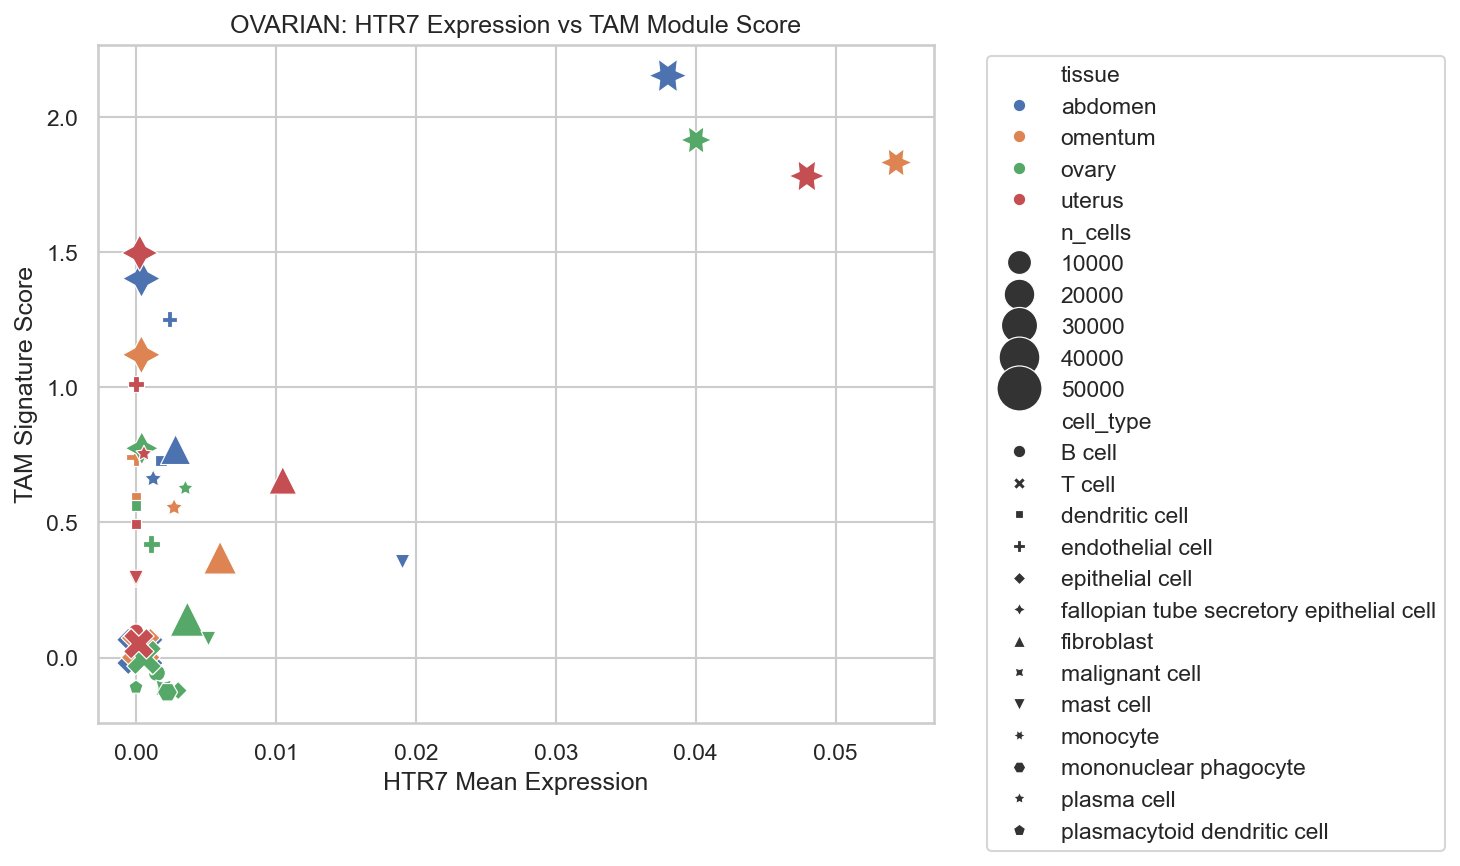

In [ ]:
tam_file = os.path.join(out_dir, f'htr7_tam_scoring_{cancer}{analysis_suffix}.csv')
if os.path.exists(tam_file):
    df_tam = pd.read_csv(tam_file)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_tam, x='HTR7_mean_expr', y='TAM_module_score', 
                    size='n_cells', hue='tissue', style='cell_type', sizes=(50, 500))
    plt.title(f'{cancer.upper()}: HTR7 Expression vs TAM Module Score')
    plt.xlabel('HTR7 Mean Expression')
    plt.ylabel('TAM Signature Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    raise RuntimeError(f"Missing required data: {tam_file}. Failing gracefully per data integrity rules.")


## 2. Full Serotonin Axis Overview
Expression of synthesis, transport, degradation, and receptor genes across cell types.


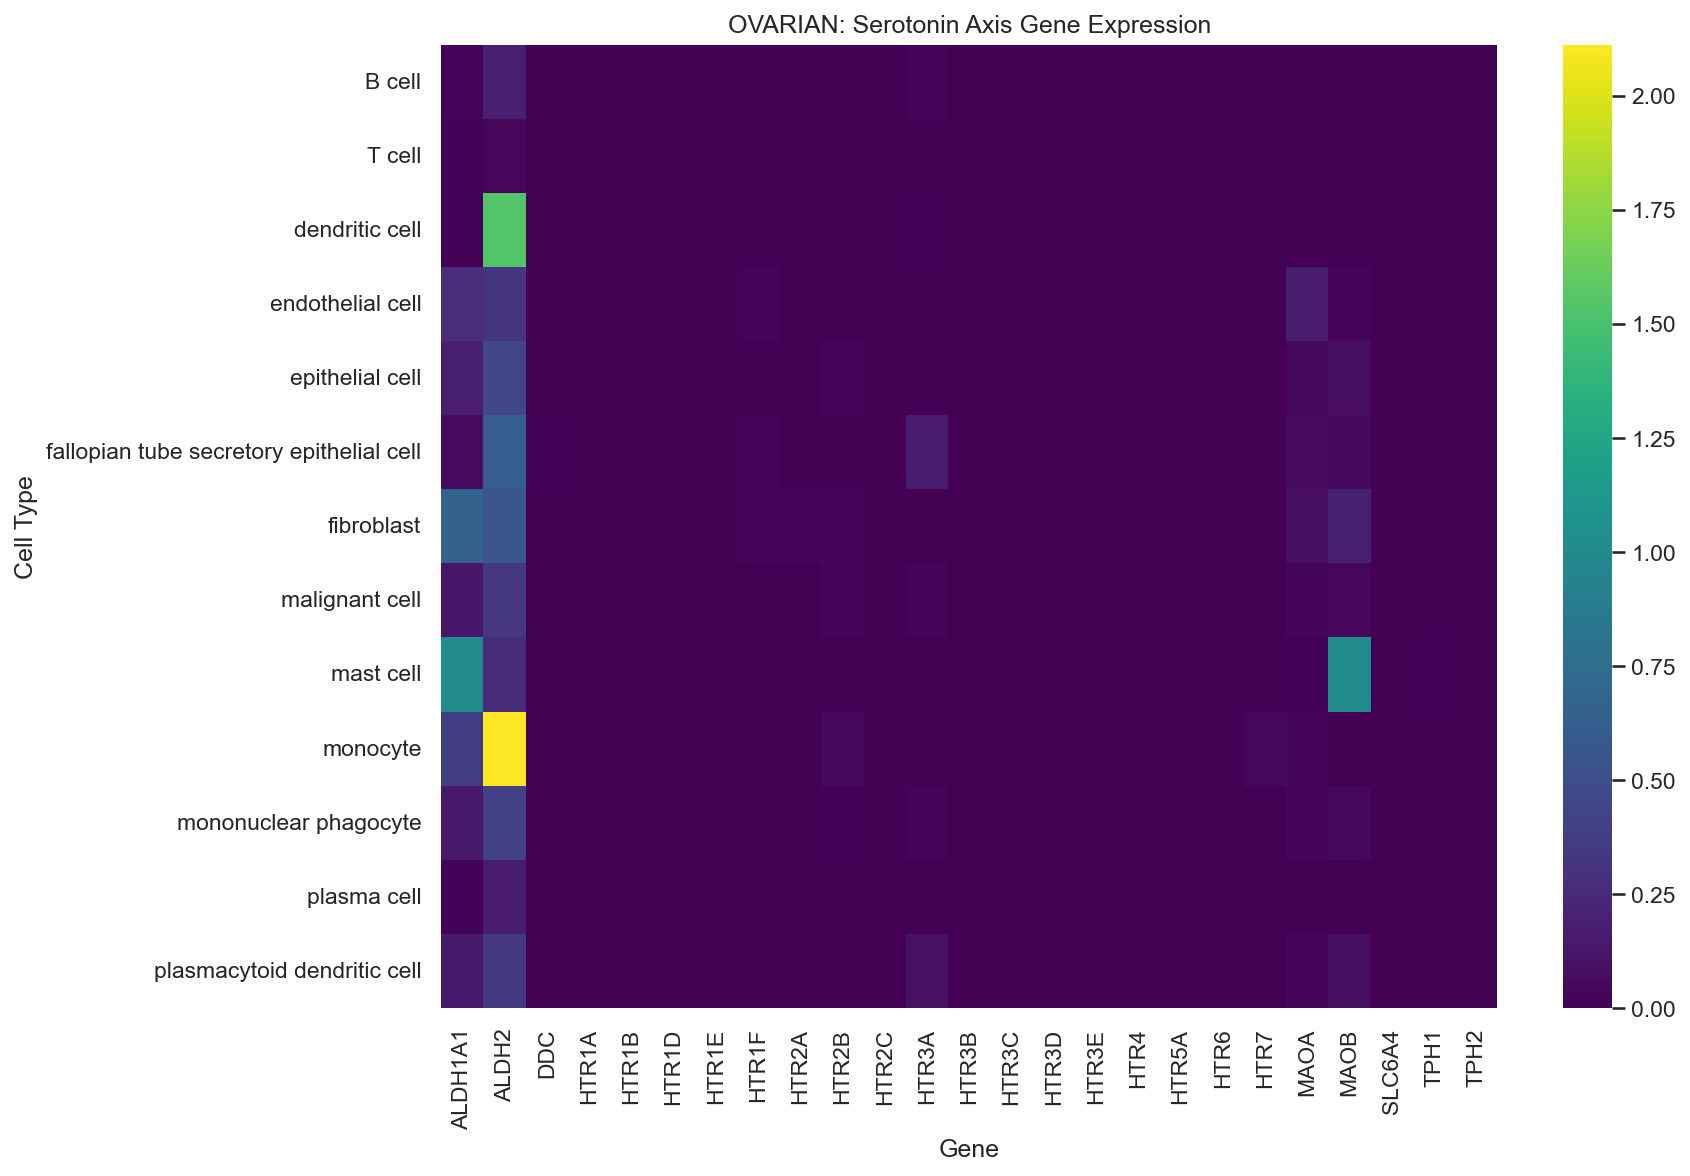

In [ ]:
sero_file = os.path.join(out_dir, f'serotonin_full_axis_{cancer}{analysis_suffix}.csv')
if os.path.exists(sero_file):
    df_sero = pd.read_csv(sero_file)
    
    # Pivot for heatmap
    pivot_df = df_sero.pivot_table(index='cell_type', columns='gene', values='mean_expr', fill_value=0)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_df, cmap='viridis', annot=False)
    plt.title(f'{cancer.upper()}: Serotonin Axis Gene Expression')
    plt.ylabel('Cell Type')
    plt.xlabel('Gene')
    plt.tight_layout()
    plt.show()
else:
    raise RuntimeError(f"Missing required data: {sero_file}. Failing gracefully per data integrity rules.")


## 3. Inositol - HR Repair Correlation
Correlation between the Inositol Phosphate pathway (IP4) and HR repair signature.


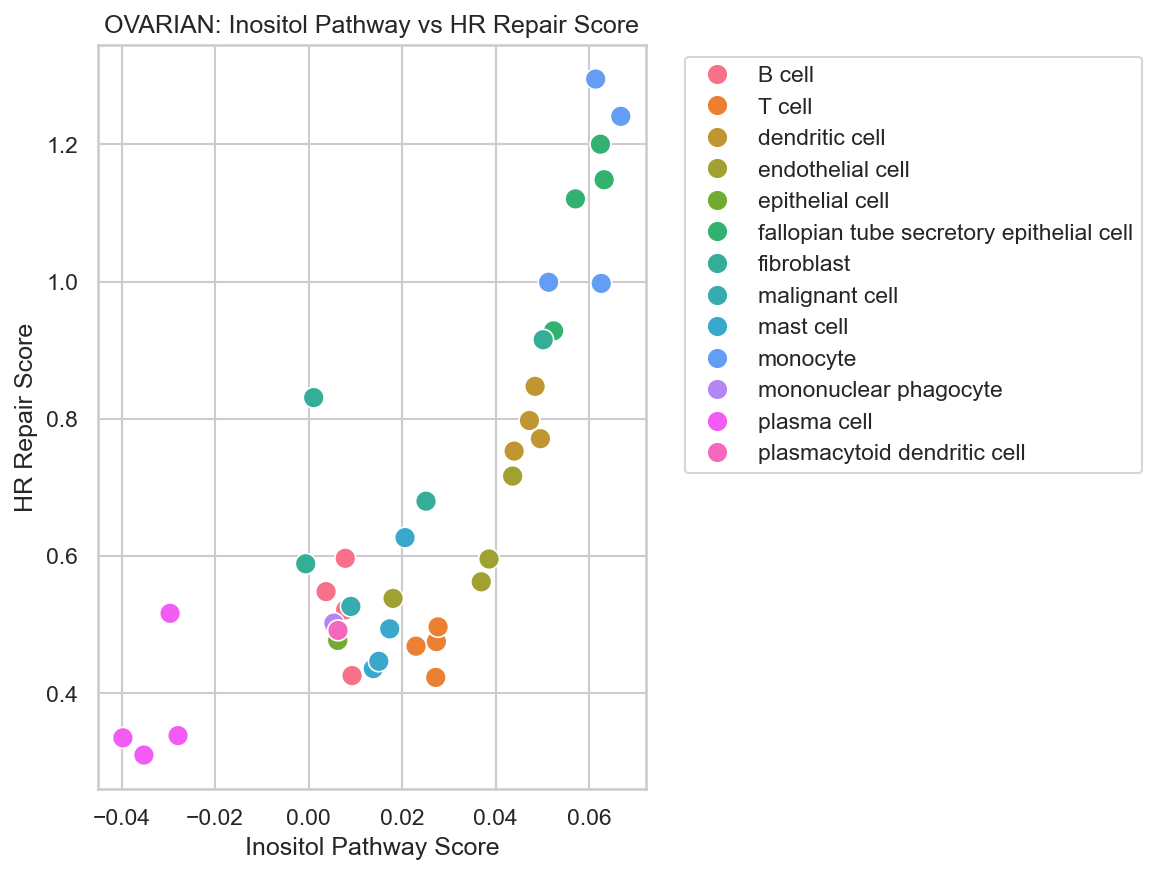

In [ ]:
hr_file = os.path.join(out_dir, f'inositol_hr_correlation_{cancer}{analysis_suffix}.csv')
if os.path.exists(hr_file):
    df_hr = pd.read_csv(hr_file)
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_hr, x='inositol_score', y='hr_score', hue='cell_type', s=100)
    plt.title(f'{cancer.upper()}: Inositol Pathway vs HR Repair Score')
    plt.xlabel('Inositol Pathway Score')
    plt.ylabel('HR Repair Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    raise RuntimeError(f"Missing required data: {hr_file}. Failing gracefully per data integrity rules.")


## 4. Extracellular Vesicle (EV) Machinery Potential
Scores for EV biogenesis, cargo sorting, and serotonin-dependent secretion.


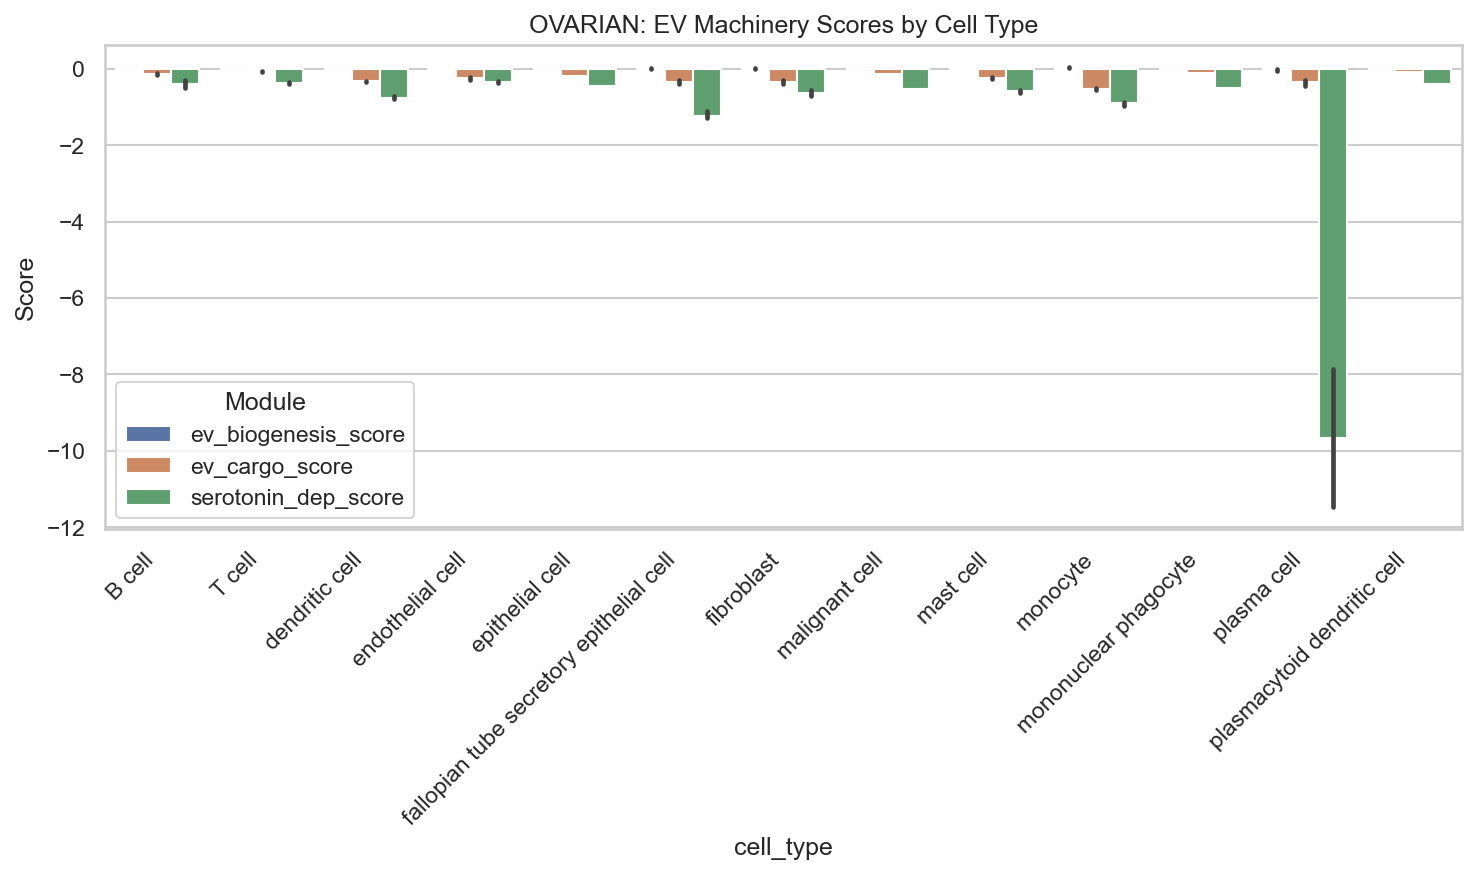

In [ ]:
ev_file = os.path.join(out_dir, f'ev_machinery_{cancer}{analysis_suffix}.csv')
if os.path.exists(ev_file):
    df_ev = pd.read_csv(ev_file)
    
    # Melt for grouped bar chart
    df_melt = df_ev.melt(id_vars=['cancer', 'cell_type', 'tissue'], 
                         value_vars=['ev_biogenesis_score', 'ev_cargo_score', 'serotonin_dep_score'],
                         var_name='Module', value_name='Score')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melt, x='cell_type', y='Score', hue='Module')
    plt.title(f'{cancer.upper()}: EV Machinery Scores by Cell Type')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    raise RuntimeError(f"Missing required data: {ev_file}. Failing gracefully per data integrity rules.")


## 5. Export Report
Exporting the analysis to HTML format.


In [ ]:
import subprocess
import sys

notebook_filename = 'serotonin_axis_spatial_mapping.ipynb'
output_html = os.path.join(out_dir, f'serotonin_axis_report_{cancer}{analysis_suffix}')

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin):
    jupyter_bin = 'jupyter'

cmd = [jupyter_bin, 'nbconvert', '--to', 'html', notebook_filename, '--output', output_html]
res = subprocess.run(cmd, capture_output=True, text=True)
if res.returncode == 0:
    print(f"Successfully exported to {output_html}.html")
else:
    print("HTML export failed.")
    print(res.stderr)
